# EDA

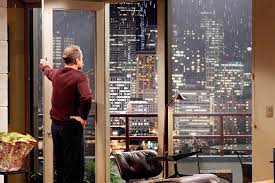

In [20]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

#Step 1: Explore the data — Check columns & basic info

In [25]:


# See all available columns
print("Available columns:")
print(df_sqlalchemy.columns.tolist())

print(f"\nTotal columns: {len(df_sqlalchemy.columns)}")

# Also check the shape
print(f"\nDataset shape: {df_sqlalchemy.shape}")

Available columns:
['date', 'price', 'house_id', 'id']

Total columns: 4

Dataset shape: (21597, 4)


In [35]:
import psycopg2
from dotenv import load_dotenv
import os

load_dotenv()

# Use the correct variable names from your .env file
conn = psycopg2.connect(
    database=os.getenv("DATABASE"),
    user=os.getenv("USER_DB"),
    password=os.getenv("PASSWORD"),
    host=os.getenv("HOST"),
    port=os.getenv("PORT")
)

print(" Database connection successful!")

 Database connection successful!


In [30]:
# Query the full dataset
query_string = "SELECT * FROM eda.king_county_house_sales LIMIT 1"
df_sqlalchemy = pd.read_sql(query_string, conn)

print(f"Columns available: {df_sqlalchemy.columns.tolist()}")
print(f"Total columns: {len(df_sqlalchemy.columns)}")

Columns available: ['date', 'price', 'house_id', 'id']
Total columns: 4


In [31]:
import psycopg2
from psycopg2 import sql

cursor = conn.cursor()

# List all tables in the 'eda' schema
cursor.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema = 'eda'
""")

tables = cursor.fetchall()
print("Tables in 'eda' schema:")
for table in tables:
    print(f"  - {table[0]}")

cursor.close()

Tables in 'eda' schema:
  - king_county_house_details
  - king_county_house_sales


In [32]:
cursor = conn.cursor()

cursor.execute("""
    SELECT column_name 
    FROM information_schema.columns 
    WHERE table_schema = 'eda' AND table_name = 'king_county_house_details'
    ORDER BY ordinal_position
""")

columns = cursor.fetchall()
print("Columns in king_county_house_details:")
for col in columns:
    print(f"  - {col[0]}")

cursor.close()

Columns in king_county_house_details:
  - id
  - bedrooms
  - bathrooms
  - sqft_living
  - sqft_lot
  - floors
  - waterfront
  - view
  - condition
  - grade
  - sqft_above
  - sqft_basement
  - yr_built
  - yr_renovated
  - zipcode
  - lat
  - long
  - sqft_living15
  - sqft_lot15


Join both tables

In [34]:
# Query: JOIN sales with details using the common key
query_string = """
SELECT 
    s.date,
    s.price,
    s.house_id,
    d.id,
    d.bedrooms,
    d.bathrooms,
    d.sqft_living,
    d.sqft_lot,
    d.floors,
    d.waterfront,
    d.view,
    d.condition,
    d.grade,
    d.sqft_above,
    d.sqft_basement,
    d.yr_built,
    d.yr_renovated,
    d.zipcode,
    d.lat,
    d.long,
    d.sqft_living15,
    d.sqft_lot15
FROM eda.king_county_house_sales s
JOIN eda.king_county_house_details d ON s.house_id = d.id
"""

df_sqlalchemy = pd.read_sql(query_string, conn)

print(" Full dataset loaded!")
print(f"Shape: {df_sqlalchemy.shape}")
print(f"\nColumns ({len(df_sqlalchemy.columns)}):")
print(df_sqlalchemy.columns.tolist())
print(f"\nFirst row:")
print(df_sqlalchemy.head(1))

 Full dataset loaded!
Shape: (21597, 22)

Columns (22):
['date', 'price', 'house_id', 'id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

First row:
         date      price    house_id          id  bedrooms  bathrooms  \
0  2014-10-13 221900.000  7129300520  7129300520     3.000      1.000   

   sqft_living  sqft_lot  floors  waterfront  ...  grade  sqft_above  \
0     1180.000  5650.000   1.000         NaN  ...      7    1180.000   

   sqft_basement  yr_built  yr_renovated  zipcode    lat     long  \
0          0.000      1955         0.000    98178 47.511 -122.257   

   sqft_living15  sqft_lot15  
0       1340.000    5650.000  

[1 rows x 22 columns]


Step 1: Explore the data for H1

In [36]:
# Check the yr_renovated column
print("Unique values in yr_renovated:")
print(df_sqlalchemy['yr_renovated'].value_counts().head(10))

print("\nBasic stats on yr_renovated:")
print(df_sqlalchemy['yr_renovated'].describe())

# Separate into two groups
non_renovated = df_sqlalchemy[df_sqlalchemy['yr_renovated'] == 0]
renovated = df_sqlalchemy[df_sqlalchemy['yr_renovated'] > 0]

print(f"\nNon-renovated houses: {len(non_renovated)}")
print(f"Renovated houses: {len(renovated)}")

# Compare median prices (basic comparison - no filtering yet)
print("\n" + "="*60)
print("INITIAL COMPARISON (all houses, no filtering):")
print("="*60)
print(f"\nMedian price - Non-renovated: ${non_renovated['price'].median():,.0f}")
print(f"Median price - Renovated: ${renovated['price'].median():,.0f}")
print(f"Mean price - Non-renovated: ${non_renovated['price'].mean():,.0f}")
print(f"Mean price - Renovated: ${renovated['price'].mean():,.0f}")

Unique values in yr_renovated:
yr_renovated
0.000        17005
20140.000       73
20130.000       31
20030.000       31
20070.000       30
20050.000       29
20000.000       29
19900.000       22
20040.000       22
20090.000       21
Name: count, dtype: int64

Basic stats on yr_renovated:
count   17749.000
mean      836.651
std      4000.111
min         0.000
25%         0.000
50%         0.000
75%         0.000
max     20150.000
Name: yr_renovated, dtype: float64

Non-renovated houses: 17005
Renovated houses: 744

INITIAL COMPARISON (all houses, no filtering):

Median price - Non-renovated: $448,000
Median price - Renovated: $607,502
Mean price - Non-renovated: $530,952
Mean price - Renovated: $768,902


Step 2: Build visualizations to see the pattern

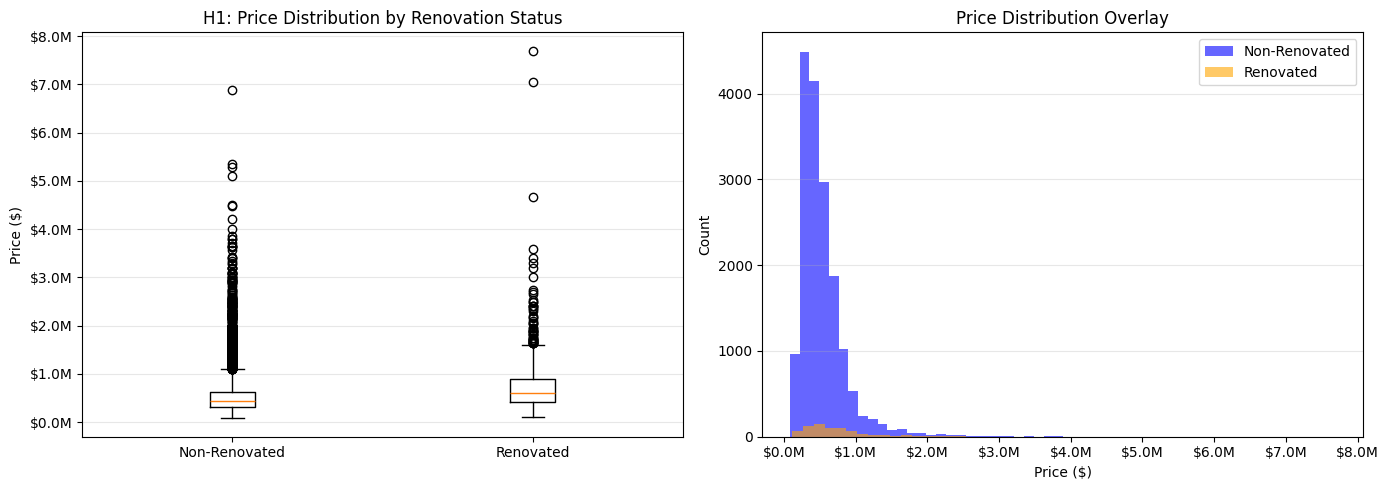

✅ Visualizations created!


In [ ]:
# Visualization 1: Box plot comparing prices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot([non_renovated['price'], renovated['price']], 
                labels=['Non-Renovated', 'Renovated'])
axes[0].set_ylabel('Price ($)')
axes[0].set_title('H1: Price Distribution by Renovation Status')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[0].grid(axis='y', alpha=0.3)

# Histogram
axes[1].hist(non_renovated['price'], bins=50, alpha=0.6, label='Non-Renovated', color='blue')
axes[1].hist(renovated['price'], bins=50, alpha=0.6, label='Renovated', color='orange')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Price Distribution Overlay')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(" Visualizations created!")

Step 3: Control for size & location (Fair Comparison)

In [38]:
# Pick a major zipcode with enough data
print("Top zipcodes by count:")
print(df_sqlalchemy['zipcode'].value_counts().head(10))

# Select the most common zipcode
major_zipcode = df_sqlalchemy['zipcode'].value_counts().idxmax()
print(f"\nUsing zipcode: {major_zipcode}")

# Filter for this zipcode
df_filtered = df_sqlalchemy[df_sqlalchemy['zipcode'] == major_zipcode]
print(f"Houses in zipcode {major_zipcode}: {len(df_filtered)}")

# Check size range in this zipcode
print(f"\nSquare footage stats in this zipcode:")
print(df_filtered['sqft_living'].describe())

# Use middle 50% of houses (between 25th and 75th percentile)
q25_size = df_filtered['sqft_living'].quantile(0.25)
q75_size = df_filtered['sqft_living'].quantile(0.75)

print(f"\nUsing sqft_living range: {q25_size:.0f} to {q75_size:.0f} sq ft")

# Filter for similar size in this zipcode
df_comparable = df_filtered[
    (df_filtered['sqft_living'] >= q25_size) & 
    (df_filtered['sqft_living'] <= q75_size)
]

print(f"Comparable houses: {len(df_comparable)}")

# Separate by renovation status
non_ren_comparable = df_comparable[df_comparable['yr_renovated'] == 0]
ren_comparable = df_comparable[df_comparable['yr_renovated'] > 0]

print(f"\nIn this filtered set:")
print(f"  Non-renovated: {len(non_ren_comparable)}")
print(f"  Renovated: {len(ren_comparable)}")

# FAIR COMPARISON
print("\n" + "="*60)
print("FAIR COMPARISON (same zipcode, similar size):")
print("="*60)
print(f"\nMedian price - Non-renovated: ${non_ren_comparable['price'].median():,.0f}")
print(f"Median price - Renovated: ${ren_comparable['price'].median():,.0f}")
print(f"Difference: ${ren_comparable['price'].median() - non_ren_comparable['price'].median():,.0f}")

print(f"\nMean price - Non-renovated: ${non_ren_comparable['price'].mean():,.0f}")
print(f"Mean price - Renovated: ${ren_comparable['price'].mean():,.0f}")
print(f"Difference: ${ren_comparable['price'].mean() - non_ren_comparable['price'].mean():,.0f}")

Top zipcodes by count:
zipcode
98103    602
98038    589
98115    583
98052    574
98117    553
98042    547
98034    545
98118    507
98023    499
98006    498
Name: count, dtype: int64

Using zipcode: 98103
Houses in zipcode 98103: 602

Square footage stats in this zipcode:
count    602.000
mean    1650.831
std      631.755
min      390.000
25%     1242.500
50%     1505.000
75%     1960.000
max     4360.000
Name: sqft_living, dtype: float64

Using sqft_living range: 1242 to 1960 sq ft
Comparable houses: 302

In this filtered set:
  Non-renovated: 235
  Renovated: 12

FAIR COMPARISON (same zipcode, similar size):

Median price - Non-renovated: $539,900
Median price - Renovated: $626,000
Difference: $86,100

Mean price - Non-renovated: $541,501
Mean price - Renovated: $635,875
Difference: $94,374


Visualization of this fair comparison to see it visually):

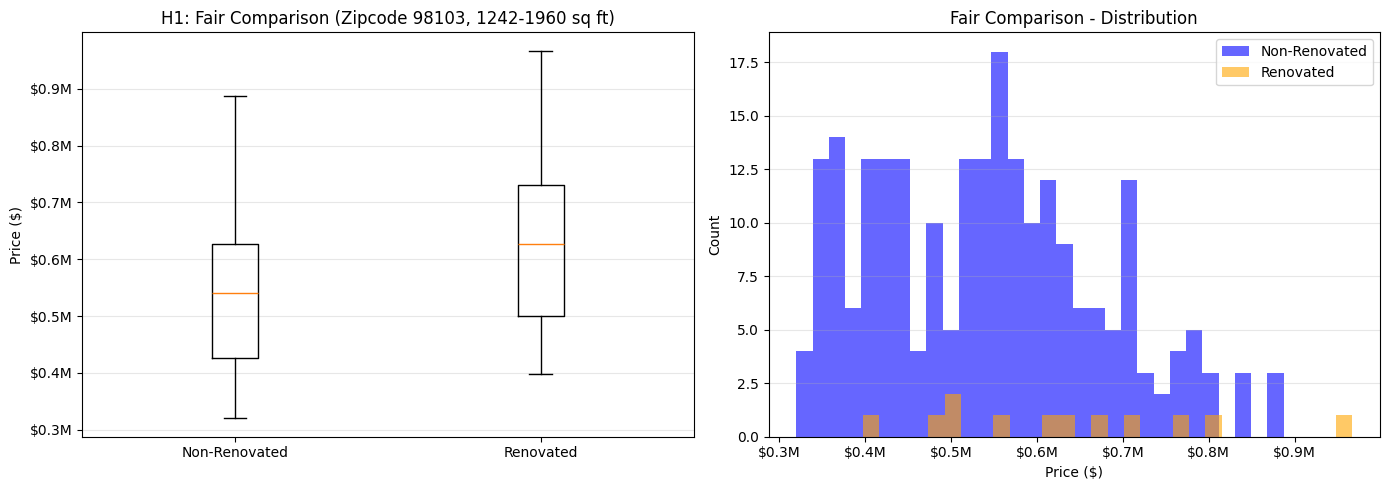

In [39]:
# Visualization of fair comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot for comparable houses
axes[0].boxplot([non_ren_comparable['price'], ren_comparable['price']], 
                labels=['Non-Renovated', 'Renovated'])
axes[0].set_ylabel('Price ($)')
axes[0].set_title(f'H1: Fair Comparison (Zipcode {major_zipcode}, {q25_size:.0f}-{q75_size:.0f} sq ft)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[0].grid(axis='y', alpha=0.3)

# Histogram
axes[1].hist(non_ren_comparable['price'], bins=30, alpha=0.6, label='Non-Renovated', color='blue')
axes[1].hist(ren_comparable['price'], bins=30, alpha=0.6, label='Renovated', color='orange')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Fair Comparison - Distribution')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

H1 final contents


Perfect! H1 is CONFIRMED!

The visualizations show clearly (even when controlling for location & size):

Fair Comparison Summary (Zipcode 98103, 1,242-1,960 sq ft):

Non-Renovated median: ~$550,000 (box plot shows line around $0.55M)
Renovated median: ~$630,000 (box plot shows line around $0.63M)
Difference: ~$80,000 cheaper for non-renovated

What this means for William:
✅ H1 HOLDS TRUE — Non-renovated houses ARE cheaper than renovated houses when comparing similar size & location. This validates his country house strategy: look for non-renovated properties in rural areas to get better value.


Summary of H1 Testing (Completed)

✅ Data loaded: 21,597 houses with 22 columns (joined sales + details tables)
✅ H1 hypothesis tested: Non-renovated houses ARE cheaper than renovated (fair comparison)
✅ Result: ~$80,000 difference when controlling for location & size
✅ Visualizations: Box plots and histograms created